In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(r"C:\Users\ritha\Downloads\retail_sales_dataset.csv")

print(df.head())

   Transaction ID        Date Customer ID  Gender  Age Product Category  \
0               1  2023-11-24     CUST001    Male   34           Beauty   
1               2  2023-02-27     CUST002  Female   26         Clothing   
2               3  2023-01-13     CUST003    Male   50      Electronics   
3               4  2023-05-21     CUST004    Male   37         Clothing   
4               5  2023-05-06     CUST005    Male   30           Beauty   

   Quantity  Price per Unit  Total Amount  
0         3              50           150  
1         2             500          1000  
2         1              30            30  
3         1             500           500  
4         2              50           100  


In [3]:
print(df.info())

print(df.describe())

print(df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB
None
       Transaction ID         Age     Quantity  Price per Unit  Total Amount
count     1000.000000  1000.00000  1000.000000     1000.000000   1000.000000
mean       500.500000    41.39200     2.514000      179.890000    456.000000
std        288.819436    13.68143     1.132734      189.681356    559.997632
min          1.000000    

In [4]:
print(df.isnull().sum())

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64


In [5]:
df.dropna(inplace=True)

In [6]:
df.fillna(0, inplace=True)

In [7]:
duplicates = df.duplicated().sum()

print("Duplicate Rows:", duplicates)

df.drop_duplicates(inplace=True)

Duplicate Rows: 0


In [8]:
df["Date"] = pd.to_datetime(df["Date"])

In [9]:
df.sort_values("Date", inplace=True)

In [10]:
print(df.dtypes)

Transaction ID               int64
Date                datetime64[ns]
Customer ID                 object
Gender                      object
Age                          int64
Product Category            object
Quantity                     int64
Price per Unit               int64
Total Amount                 int64
dtype: object


In [11]:
summary = pd.DataFrame({
    "Metric": [
        "Total Records",
        "Total Customers",
        "Average Sales",
        "Maximum Sales",
        "Minimum Sales"
    ],
    "Value": [
        len(df),
        df["Customer ID"].nunique(),
        df["Total Amount"].mean(),
        df["Total Amount"].max(),
        df["Total Amount"].min()
    ]
})

print(summary)

            Metric   Value
0    Total Records  1000.0
1  Total Customers  1000.0
2    Average Sales   456.0
3    Maximum Sales  2000.0
4    Minimum Sales    25.0


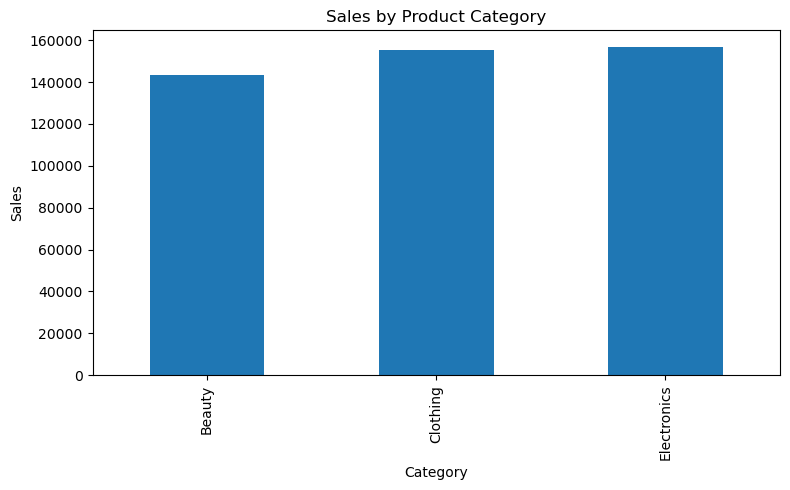

In [12]:
sales = df.groupby("Product Category")["Total Amount"].sum()

plt.figure(figsize=(8,5))

sales.plot(kind="bar")

plt.title("Sales by Product Category")

plt.xlabel("Category")

plt.ylabel("Sales")

plt.tight_layout()

plt.show()

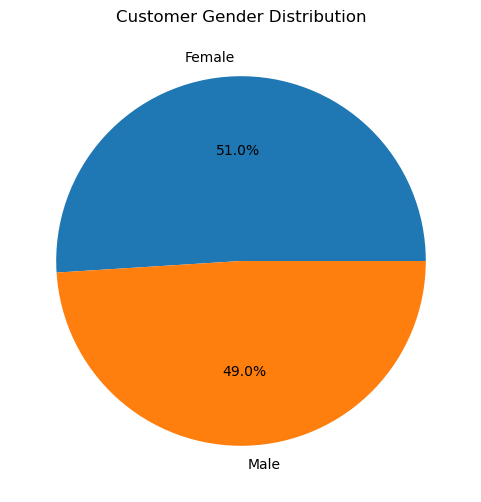

In [13]:
gender = df["Gender"].value_counts()

plt.figure(figsize=(6,6))

gender.plot(kind="pie", autopct="%1.1f%%")

plt.ylabel("")

plt.title("Customer Gender Distribution")

plt.show()

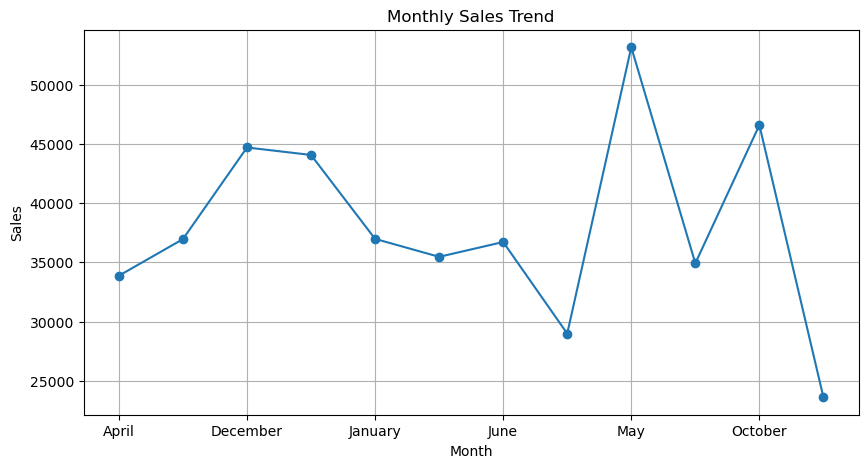

In [14]:
df["Month"] = df["Date"].dt.month_name()

monthly = df.groupby("Month")["Total Amount"].sum()

plt.figure(figsize=(10,5))

monthly.plot(marker="o")

plt.title("Monthly Sales Trend")

plt.xlabel("Month")

plt.ylabel("Sales")

plt.grid(True)

plt.show()

In [15]:
df.to_csv("cleaned_retail_sales.csv", index=False)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


In [16]:
with pd.ExcelWriter("sales_report.xlsx") as writer:
    df.to_excel(writer, sheet_name="Cleaned Data", index=False)
    summary.to_excel(writer, sheet_name="Summary", index=False)

print("Excel report generated successfully.")

Excel report generated successfully.


In [17]:
plt.figure(figsize=(8,5))

sales.plot(kind="bar")

plt.title("Sales by Product Category")

plt.tight_layout()

plt.savefig("visual_summary.png")

plt.close()